
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E02_sklearn.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Scikit-learn exercises 

---
These are introductory exercises in Machine learning with focus in **scikit-learn** .

<p class = "alert alert-info" role="alert"><b>Note</b> that sometimes you don't get exactly the same answer as I get, but it doesn't neccessarily mean it is wrong. Could be some parameters, randomization, that we have different. Also very important is that in the future there won't be any answer sheets, use your skills in data analysis, mathematics and statistics to back up your work.</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. EDA (*)

In the whole exercise, we will work with the "mpg" dataset from seaborn dataset. Start by loading dataset "mpg" from the ```load_dataset``` method in seaborn module. The goal will be to use linear regression to predict mpg - miles per gallon. 

&nbsp; a) Start by doing some initial EDA such as info(), describe() and figure out what you want to do with the missing values.

&nbsp; b) Use describe only on those columns that are relevant to get statistical information from. 

&nbsp; c) Make some plots on some of the columns that you find interesting.

&nbsp; d) Check if there are any columns you might want to drop. 

<details>

<summary>Answer</summary>

a) I have chosen to drop the rows, but it doesn't neccessary have to be the best method. Maybe some NaNs should be filled somehow?

b)
|      |      mpg |   cylinders |   displacement |   horsepower |   weight |   acceleration |
|:-----|---------:|------------:|---------------:|-------------:|---------:|---------------:|
| mean | 23.4459  |     5.47194 |        194.412 |     104.469  | 2977.58  |       15.5413  |
| std  |  7.80501 |     1.70578 |        104.644 |      38.4912 |  849.403 |        2.75886 |
| min  |  9       |     3       |         68     |      46      | 1613     |        8       |
| 25%  | 17       |     4       |        105     |      75      | 2225.25  |       13.775   |
| 50%  | 22.75    |     4       |        151     |      93.5    | 2803.5   |       15.5     |
| 75%  | 29       |     8       |        275.75  |     126      | 3614.75  |       17.025   |
| max  | 46.6     |     8       |        455     |     230      | 5140     |       24.8     |


c) Here are some example plots

<img src="../assets/EDA_mpg.png" height="400"/>

d) I have chosen to drop the columns origin and name. Think yourself if it is reasonable and feel free to experiment. Also there might be some domain experts in our class, that you can ask. 

</details>

---

In [215]:
import seaborn as sns

mpg = sns.load_dataset('mpg')

In [216]:
# a)
mpg.info()
mpg.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [217]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [218]:
mpg = mpg.dropna()

The dataset contains 398 observations and only 6 missing values in the variable horsepower (≈1.5% missing data). Since the missing data is of such small proportion and bound to one variable, I chose to drop these columns.

In [219]:
# b)
numeric_columns = [
    'mpg',
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'model_year'
]
mpg[numeric_columns].describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


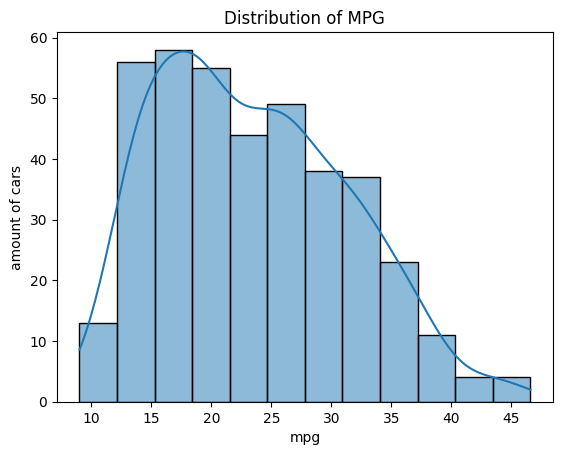

In [220]:
# c)
import matplotlib.pyplot as plt

sns.histplot(mpg['mpg'], kde=True)
plt.title('Distribution of MPG')
plt.xlabel('mpg')
plt.ylabel('amount of cars')
plt.show()

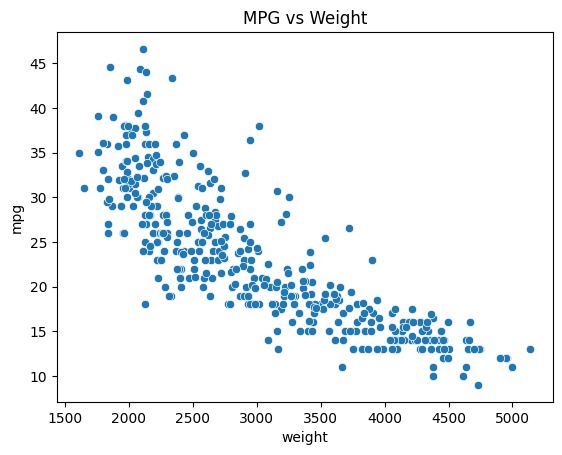

In [221]:
sns.scatterplot(x='weight', y='mpg', data=mpg)
plt.title('MPG vs Weight')
plt.show()

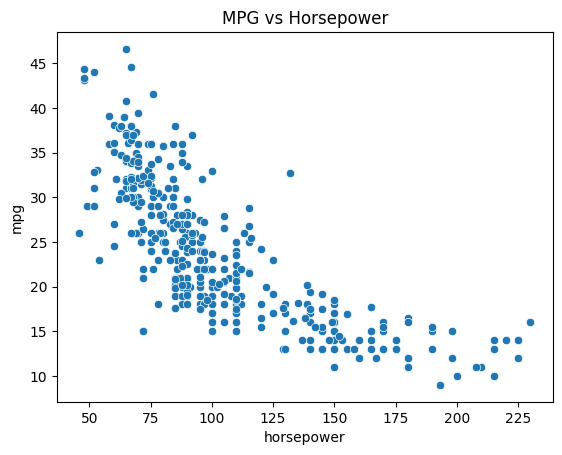

In [222]:
sns.scatterplot(x='horsepower', y='mpg', data=mpg)
plt.title('MPG vs Horsepower')
plt.show()

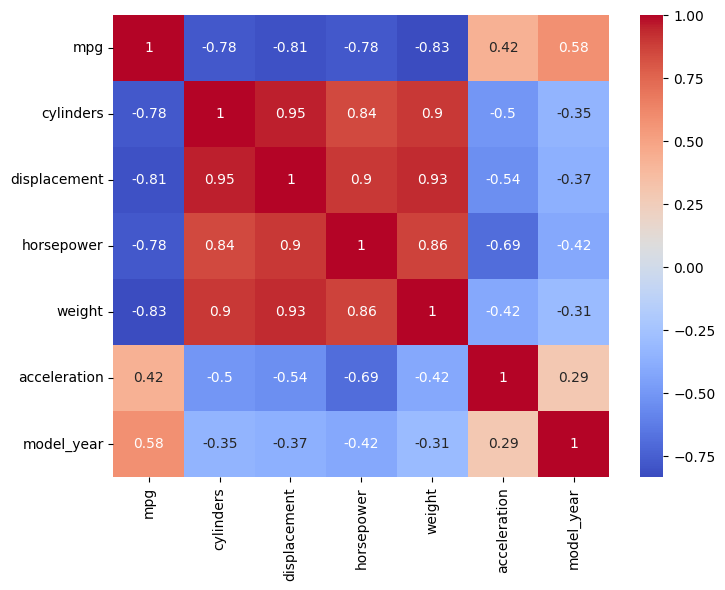

In [223]:
plt.figure(figsize=(8,6))
sns.heatmap(mpg.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

**Interpretation of the heatmap:**
<br> Values close to 1 or -1 = strong correlation
<br> Values close to 0 = weak correlation
<br> Red = positive correlation
<br> Blue = negative correlation

**Correlation with MPG:**
<br> weight (-0.83) → strong negative correlation. Heavier cars have lower mpg.
<br> displacement (-0.81) → strong negative correlation. Larger engines have lower mpg.
<br> horsepower (-0.78) → strong negative correlation. More horsepower results in lower mpg.
<br> cylinders (-0.78) → strong negative correlation.
<br> model_year (0.58) → positive correlation. Newer cars have higher mpg.
<br> acceleration (0.42) → weaker positive correlation.

**Conclusion:**
<br> The correlation matrix shows strong correlations between mpg and weight, displacement, horsepower, and cylinders. It appears that larger and heavier cars have lower fuel efficiency. Model_year shows a positive correlation, indicating that newer cars tend to have higher mpg.

In [224]:
# d)
mpg = mpg.drop(columns=['origin', 'name'])
mpg.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 24.5 KB


I chose to drop the columns origin and name.
origin is a categorical variable that contains string values (e.g. USA, Japan, Europe). Linear regression cannot handle string variables unless they are first converted into dummy-variables. To keep the model simple, I chose to exclude origin.
name contains only the name of the car and does not provide with any useful numerical information for the regression model, and was therefore removed.

## 1. Train|test split (*)

We want to predict the "mpg", split up X and y, and perform train|test split using scikit-learn. Choose test_size of 0.2 and random_state 42. Control the shapes of each X_train, X_test, y_train, y_test.  

<details>

<summary>Answer</summary>

Do a manual calculation to check against the shapes after train|test split. 

</details>

---

In [225]:
from sklearn.model_selection import train_test_split

X = mpg.drop(columns=['mpg'])
y = mpg['mpg']

In [226]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [227]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(313, 6)
(79, 6)
(313,)
(79,)


**Interpretation of the printed results:**
<br> X_train → (313, 6) = 313 rows (observations) and 6 columns (features). The model is trained on 313 cars using 6 predictors.
<br> X_test → (79, 6) = 79 observations and the same 6 features as X_train. This is the test set.
<br> y_train → (313,) = 313 target values (mpg values).
<br> y_test → (79,) = 79 mpg values in the test set.

**Manual calculation:**
<br> 392 × 0.2 = 78.4 ≈ 79
<br> 392 − 79 = 313

**Conclusion:**
<br> After removing missing values, the dataset contains 392 observations. With a test size of 0.2, 79 observations are assigned to the test set and 313 to the training set.
The manual calculation confirms that the shapes are correct.

## 2. Function for evaluation (*)

Create a function for training a regression model, predicting and computing the metrics MAE, MSE, RMSE. It should take in parameters of X_train, X_test, y_train, y_test, model. Now create a linear regression model using scikit-learns ```LinearRegression()``` (OLS normal equation with SVD) and call your function to get metrics. 

<details>

<summary>Answer</summary>

MAE 2.50

MSE 10.50

RMSE 3.24

</details>

In [228]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def predict_and_compute_metrics(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    
    y_predict = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_predict)
    mse = mean_squared_error(y_test, y_predict)
    rmse = np.sqrt(mse)

    return mae, mse, rmse

In [229]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

mae, mse, rmse = predict_and_compute_metrics(X_train, X_test, y_train, y_test, model)

print('MAE:', round(mae, 2))
print('MSE:', round(mse, 2))
print('RMSE:', round(rmse, 2))

MAE: 2.5
MSE: 10.5
RMSE: 3.24


---
## 3. Compare models (*)

Create the following models 
- Linear regression (SVD)
- Linear regression (SVD) with scaled data (feature standardization)
- Polynomial linear regression with degree 1
- Polynomial linear regression with degree 2
- Polynomial linear regression with degree 3

Make a DataFrame with evaluation metrics and model. Which model performed overall best?

<details>

<summary>Answer</summary>

|      |   Linear regr. SVD |   Linear regr. SVD scaled |   Linear regr. SGD |   Polynom. regr. deg 1 |   Polynom. regr. deg 2 |   Polynom. regr. deg 3 |
|:-----|-------------------:|--------------------------:|-------------------:|-----------------------:|-----------------------:|-----------------------:|
| mae  |            2.50386 |                   2.50386 |            2.53515 |                2.50386 |                1.98048 |                2.11788 |
| mse  |           10.5024  |                  10.5024  |           10.8908  |               10.5024  |                7.41986 |                9.27353 |
| rmse |            3.24074 |                   3.24074 |            3.30012 |                3.24074 |                2.72394 |                3.04525 |

</details>

---

In [230]:
import pandas as pd
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

results = {}

In [231]:
# Linear Regression (SVD)
model = LinearRegression()
mae, mse, rmse = predict_and_compute_metrics(
    X_train, X_test, y_train, y_test, model)
results["Linear regr. SVD"] = [mae, mse, rmse]

In [232]:
# Linear Regression (SVD scaled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
mae, mse, rmse = predict_and_compute_metrics(
    X_train_scaled, X_test_scaled, y_train, y_test, model)
results["Linear regr. SVD scaled"] = [mae, mse, rmse]

In [233]:
# Linear Regression (SGD)
model = SGDRegressor(max_iter=10000, tol=1e-3)
mae, mse, rmse = predict_and_compute_metrics(
    X_train_scaled, X_test_scaled, y_train, y_test, model)
results["Linear regr. SGD"] = [mae, mse, rmse]

In [234]:
# Polynomial degree 1
poly1 = PolynomialFeatures(degree=1)
X_train_poly1 = poly1.fit_transform(X_train_scaled)
X_test_poly1 = poly1.transform(X_test_scaled)

model = LinearRegression()
mae, mse, rmse = predict_and_compute_metrics(
    X_train_poly1, X_test_poly1, y_train, y_test, model)
results["Polynom. regr. deg 1"] = [mae, mse, rmse]

In [235]:
# Polynomial degree 2
poly2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly2.fit_transform(X_train_scaled)
X_test_poly2 = poly2.transform(X_test_scaled)

model = LinearRegression()
mae, mse, rmse = predict_and_compute_metrics(
    X_train_poly2, X_test_poly2, y_train, y_test, model)
results["Polynom. regr. deg 2"] = [mae, mse, rmse]

In [236]:
# Polynomial degree 3
poly3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly3.fit_transform(X_train_scaled)
X_test_poly3 = poly3.transform(X_test_scaled)

model = LinearRegression()
mae, mse, rmse = predict_and_compute_metrics(
    X_train_poly3, X_test_poly3, y_train, y_test, model)
results["Polynom. regr. deg 3"] = [mae, mse, rmse]

In [237]:
results_df = pd.DataFrame(results, index=["mae", "mse", "rmse"])

results_df

,Linear regr. SVD,Linear regr. SVD scaled,Linear regr. SGD,Polynom. regr. deg 1,Polynom. regr. deg 2,Polynom. regr. deg 3
mae,2.503860,2.503860,2.542489,2.503860,1.980477,2.117877
mse,10.502370,10.502370,10.918694,10.502370,7.419858,9.273527
rmse,3.240736,3.240736,3.304345,3.240736,2.723942,3.045247



## 4. Further explorations (**)

Feel free to further explore the dataset, for example you could choose to 
- drop different columns
- find out feature importance in polynomial models
- fine tune further for a specific model by exploring hyperparameters (check documentation which type of parameters that can be changed)

---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---